# Practical Feature Engineering in Machine Learning: Must-Know Techniques with Real Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind, f_oneway
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    MinMaxScaler,
    OneHotEncoder,
    LabelEncoder,
    OrdinalEncoder,
    PowerTransformer,
)
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
df = pd.read_csv("preprocessed_car_dateset.csv")
print(df.shape)
df.head()

(15725, 17)


,PRICE,LEVY,MANUFACTURER,MODEL,PROD. YEAR,CATEGORY,LEATHER INTERIOR,FUEL TYPE,ENGINE VOLUME,MILEAGE_KM,CYLINDERS,GEAR BOX TYPE,DRIVE WHEELS,DOORS,WHEEL,COLOR,AIRBAGS
0,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,4-5,Left wheel,Silver,12
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000,6.0,Tiptronic,4x4,4-5,Left wheel,Black,8
2,8467,NaN,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,4-5,Right-hand drive,Black,2
3,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,4-5,Left wheel,White,0
4,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,4-5,Left wheel,Silver,4


---
## 1. Handling Missing Values

In [2]:
print(df.isnull().sum()[df.isnull().sum() > 0])

LEVY    5684
dtype: int64


In [ ]:
# Median imputation for LEVY
num_imputer = SimpleImputer(strategy="median")
df[["LEVY"]] = num_imputer.fit_transform(df[["LEVY"]])

print(f"LEVY median used for imputation: {df['LEVY'].median()}")

LEVY median used for imputation: 779.0


In [ ]:
knn_imputer = KNNImputer(n_neighbors=5)
df_knn = df.copy()
df_knn[["LEVY"]] = knn_imputer.fit_transform(df_knn[["LEVY"]])
print(f"KNN-imputed LEVY — first 5 values: {df_knn['LEVY'].head().tolist()}")

KNN-imputed LEVY — first 5 values: [1399.0, 1018.0, 779.0, 862.0, 446.0]


---
## 2. Handling Outliers

### 2.1 IQR Method

In [ ]:
Q1 = df["PRICE"].quantile(0.25)
Q3 = df["PRICE"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_iqr_clean = df[(df["PRICE"] >= lower_bound) & (df["PRICE"] <= upper_bound)]

print(f"Original dataset size: {df.shape[0]}")
print(f"After IQR outlier removal: {df_iqr_clean.shape[0]}")
print(f"Rows removed: {df.shape[0] - df_iqr_clean.shape[0]}")

Original dataset size: 15725
After IQR outlier removal: 14768
Rows removed: 957


### 2.2 Z-Score Method

In [ ]:
z_scores = np.abs(stats.zscore(df["PRICE"]))
df_zscore_clean = df[z_scores < 3]

print(f"Original dataset size: {df.shape[0]}")
print(f"After Z-score filtering: {df_zscore_clean.shape[0]}")

Original dataset size: 15725
After Z-score filtering: 15723


### 2.3 Capping Instead of Removing

In [ ]:
lower_cap = df["PRICE"].quantile(0.01)
upper_cap = df["PRICE"].quantile(0.99)
df["PRICE"] = df["PRICE"].clip(lower=lower_cap, upper=upper_cap)

# Drop INT32 MAX mileage placeholder rows
df = df[df["MILEAGE_KM"] < 2_000_000_000]

print(f"Dataset size after capping and mileage filter: {df.shape[0]}")

Dataset size after capping and mileage filter: 15718


---
## 3. Creating New Features

### 3.1 Car Age

In [ ]:
df["CAR_AGE"] = 2024 - df["PROD. YEAR"]

print(df["CAR_AGE"].describe().round(2))

count    15718.00
mean        13.47
std          6.00
min          4.00
25%         10.00
50%         12.00
75%         16.00
max         85.00
Name: CAR_AGE, dtype: float64


### 3.2 Price Per Kilometer

In [ ]:
df["PRICE_PER_KM"] = df["PRICE"] / (df["MILEAGE_KM"] + 1)

print(df["PRICE_PER_KM"].describe().round(4))

count    15718.0000
mean       383.5558
std       3269.9560
min          0.0000
25%          0.0499
50%          0.1257
75%          0.3298
max      89379.0000
Name: PRICE_PER_KM, dtype: float64


---
## 4. Handling Skewed Distributions

In [10]:
print(f"PRICE skewness: {df['PRICE'].skew():.3f}")

PRICE skewness: 1.832


In [ ]:
df["PRICE_LOG"] = np.log1p(df["PRICE"])

print(f"Log PRICE skewness: {df['PRICE_LOG'].skew():.3f}")

Log PRICE skewness: -1.719


In [ ]:
pt = PowerTransformer(method="yeo-johnson")
df[["MILEAGE_TRANSFORMED"]] = pt.fit_transform(df[["MILEAGE_KM"]])

print(f"MILEAGE_KM skewness (original):    {df['MILEAGE_KM'].skew():.3f}")
print(f"MILEAGE_KM skewness (Yeo-Johnson): {df['MILEAGE_TRANSFORMED'].skew():.3f}")

MILEAGE_KM skewness (original):    42.868
MILEAGE_KM skewness (Yeo-Johnson): 2.178


---
## 5. Scaling Numerical Features

### 5.1 Standard Scaling

In [ ]:
numerical_cols = ["MILEAGE_KM", "CYLINDERS", "CAR_AGE", "AIRBAGS"]

df_std = df.copy()
scaler = StandardScaler()
df_std[numerical_cols] = scaler.fit_transform(df_std[numerical_cols])

print("Standard Scaled (first 3 rows):")
print(df_std[numerical_cols].head(3).round(3))

Standard Scaled (first 3 rows):
   MILEAGE_KM  CYLINDERS  CAR_AGE  AIRBAGS
0      -0.024      1.336    0.088    1.341
1      -0.024      1.336   -0.079    0.358
2      -0.024     -0.426    0.754   -1.117


### 5.2 Robust Scaling

In [14]:
df_robust = df.copy()
robust_scaler = RobustScaler()
df_robust[numerical_cols] = robust_scaler.fit_transform(df_robust[numerical_cols])

print("Robust Scaled (first 3 rows):")
print(df_robust[numerical_cols].head(3).round(3))

Robust Scaled (first 3 rows):
   MILEAGE_KM  CYLINDERS  CAR_AGE  AIRBAGS
0       0.573        2.0    0.333     0.75
1       0.626        2.0    0.167     0.25
2       0.696        0.0    1.000    -0.50


### 5.3 Min-Max Scaling

In [15]:
df_minmax = df.copy()
min_max_scaler = MinMaxScaler()
df_minmax[numerical_cols] = min_max_scaler.fit_transform(df_minmax[numerical_cols])

print("Min-Max Scaled (first 3 rows):")
print(df_minmax[numerical_cols].head(3).round(3))

Min-Max Scaled (first 3 rows):
   MILEAGE_KM  CYLINDERS  CAR_AGE  AIRBAGS
0         0.0      0.333    0.123    0.750
1         0.0      0.333    0.111    0.500
2         0.0      0.200    0.173    0.125


---
## 6. Understanding Cardinality

In [ ]:
cat_cols = df.select_dtypes(include="object").columns
print(df[cat_cols].nunique().sort_values(ascending=False))

MODEL               1590
ENGINE VOLUME        107
MANUFACTURER          65
COLOR                 16
CATEGORY              11
FUEL TYPE              7
GEAR BOX TYPE          4
DRIVE WHEELS           3
DOORS                  3
LEATHER INTERIOR       2
WHEEL                  2
dtype: int64


---
## 7. Encoding Categorical Features

### 7.1 One-Hot Encoding with pandas

In [ ]:
cat_cols_ohe = ["FUEL TYPE", "GEAR BOX TYPE", "DRIVE WHEELS"]
df_encoded = pd.get_dummies(df, columns=cat_cols_ohe, drop_first=True)

print(
    "New columns:",
    [c for c in df_encoded.columns if any(cat in c for cat in cat_cols_ohe)],
)

New columns: ['FUEL TYPE_Diesel', 'FUEL TYPE_Hybrid', 'FUEL TYPE_Hydrogen', 'FUEL TYPE_LPG', 'FUEL TYPE_Petrol', 'FUEL TYPE_Plug-in Hybrid', 'GEAR BOX TYPE_Manual', 'GEAR BOX TYPE_Tiptronic', 'GEAR BOX TYPE_Variator', 'DRIVE WHEELS_Front', 'DRIVE WHEELS_Rear']


### 7.2 One-Hot Encoding with sklearn

In [ ]:
ohe = OneHotEncoder(drop="first", sparse_output=False)
encoded = ohe.fit_transform(df[["FUEL TYPE", "GEAR BOX TYPE", "DRIVE WHEELS"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(["FUEL TYPE", "GEAR BOX TYPE", "DRIVE WHEELS"]),
)
print(encoded_df.head(4))

   FUEL TYPE_Diesel  FUEL TYPE_Hybrid  FUEL TYPE_Hydrogen  FUEL TYPE_LPG  \
0               0.0               1.0                 0.0            0.0   
1               0.0               0.0                 0.0            0.0   
2               0.0               0.0                 0.0            0.0   
3               0.0               1.0                 0.0            0.0   

   FUEL TYPE_Petrol  FUEL TYPE_Plug-in Hybrid  GEAR BOX TYPE_Manual  \
0               0.0                       0.0                   0.0   
1               1.0                       0.0                   0.0   
2               1.0                       0.0                   0.0   
3               0.0                       0.0                   0.0   

   GEAR BOX TYPE_Tiptronic  GEAR BOX TYPE_Variator  DRIVE WHEELS_Front  \
0                      0.0                     0.0                 0.0   
1                      1.0                     0.0                 0.0   
2                      0.0               

In [19]:
print(ohe.categories_)

[array(['CNG', 'Diesel', 'Hybrid', 'Hydrogen', 'LPG', 'Petrol',
       'Plug-in Hybrid'], dtype=object), array(['Automatic', 'Manual', 'Tiptronic', 'Variator'], dtype=object), array(['4x4', 'Front', 'Rear'], dtype=object)]


### 7.3 Label Encoding

In [ ]:
le = LabelEncoder()
df["FUEL_TYPE_LABEL"] = le.fit_transform(df["FUEL TYPE"])

print("Classes:", le.classes_)
print()
print(
    df[["FUEL TYPE", "FUEL_TYPE_LABEL"]]
    .drop_duplicates()
    .sort_values("FUEL_TYPE_LABEL")
    .to_string(index=False)
)

Classes: ['CNG' 'Diesel' 'Hybrid' 'Hydrogen' 'LPG' 'Petrol' 'Plug-in Hybrid']

     FUEL TYPE  FUEL_TYPE_LABEL
           CNG                0
        Diesel                1
        Hybrid                2
      Hydrogen                3
           LPG                4
        Petrol                5
Plug-in Hybrid                6


### 7.4 Ordinal Encoding

In [ ]:
df["LEATHER_INTERIOR_ENCODED"] = df["LEATHER INTERIOR"].map({"Yes": 1, "No": 0})

print(df[["LEATHER INTERIOR", "LEATHER_INTERIOR_ENCODED"]].head(4))

  LEATHER INTERIOR  LEATHER_INTERIOR_ENCODED
0              Yes                         1
1               No                         0
2               No                         0
3              Yes                         1


In [ ]:
oe = OrdinalEncoder(categories=[["Manual", "Tiptronic", "Variator", "Automatic"]])
df[["GEARBOX_ENCODED"]] = oe.fit_transform(df[["GEAR BOX TYPE"]])

print(
    df[["GEAR BOX TYPE", "GEARBOX_ENCODED"]]
    .drop_duplicates()
    .sort_values("GEARBOX_ENCODED")
    .to_string(index=False)
)

GEAR BOX TYPE  GEARBOX_ENCODED
       Manual              0.0
    Tiptronic              1.0
     Variator              2.0
    Automatic              3.0


### 7.5 Frequency Encoding

In [ ]:
freq_map = df["MANUFACTURER"].value_counts(normalize=True)
df["MANUFACTURER_FREQ"] = df["MANUFACTURER"].map(freq_map)

print(
    df[["MANUFACTURER", "MANUFACTURER_FREQ"]]
    .drop_duplicates()
    .sort_values("MANUFACTURER_FREQ", ascending=False)
    .head(6)
    .to_string(index=False)
)

 MANUFACTURER  MANUFACTURER_FREQ
      HYUNDAI           0.194045
       TOYOTA           0.182084
MERCEDES-BENZ           0.092251
    CHEVROLET           0.061585
         FORD           0.060758
          BMW           0.058722


### 7.6 Count Encoding

In [ ]:
count_map = df["MODEL"].value_counts()
df["MODEL_COUNT"] = df["MODEL"].map(count_map)

print(
    df[["MODEL", "MODEL_COUNT"]]
    .drop_duplicates()
    .sort_values("MODEL_COUNT", ascending=False)
    .head(6)
    .to_string(index=False)
)

   MODEL  MODEL_COUNT
   Prius          945
  Sonata          821
 Elantra          720
   Camry          581
Santa FE          486
     FIT          422


### 7.7 Target Encoding

In [ ]:
def target_encode(df, col, target):
    means = df.groupby(col)[target].mean()
    return df[col].map(means)


df["MANUFACTURER_ENCODED"] = target_encode(df, "MANUFACTURER", "PRICE")

brand_means = df.groupby("MANUFACTURER")["PRICE"].mean().sort_values(ascending=False)
print(brand_means.head(5).apply(lambda x: f"{x:,.1f}"))

MANUFACTURER
LAMBORGHINI     89,379.0
BENTLEY         89,379.0
FERRARI         60,683.5
ASTON MARTIN    54,000.0
TESLA           53,941.0
Name: PRICE, dtype: object


### 7.8 Binary Encoding

In [ ]:
import math

le_mfr = LabelEncoder()
df["MANUFACTURER_LABEL"] = le_mfr.fit_transform(df["MANUFACTURER"])

n_bits = 7  # ceil(log2(65)) = 7
for bit in range(n_bits):
    df[f"MANUFACTURER_bit_{bit}"] = df["MANUFACTURER_LABEL"].apply(
        lambda x: (x >> bit) & 1
    )

n_unique = df["MANUFACTURER"].nunique()
print(f"MANUFACTURER: {n_unique} unique values")
print(f"  One-Hot Encoding: {n_unique - 1} columns")
print(f"  Binary Encoding:  {math.ceil(math.log2(n_unique))} columns")

n_model = df["MODEL"].nunique()
print(f"\nMODEL: {n_model} unique values")
print(f"  One-Hot Encoding: {n_model - 1} columns")
print(f"  Binary Encoding:  {math.ceil(math.log2(n_model))} columns")

MANUFACTURER: 65 unique values
  One-Hot Encoding: 64 columns
  Binary Encoding:  7 columns

MODEL: 1590 unique values
  One-Hot Encoding: 1589 columns
  Binary Encoding:  11 columns


---
## 8. Binning Continuous Features

In [ ]:
df["MILEAGE_BUCKET"] = pd.cut(
    df["MILEAGE_KM"],
    bins=[0, 50000, 100000, 200000, 999_000_000],
    labels=["Low", "Medium", "High", "Very High"],
)

print(df["MILEAGE_BUCKET"].value_counts())

MILEAGE_BUCKET
High         6529
Medium       3413
Very High    2878
Low          2281
Name: count, dtype: int64


In [ ]:
df["AGE_GROUP"] = pd.cut(
    df["CAR_AGE"], bins=[0, 5, 10, 15, 100], labels=["New", "Recent", "Mid-Age", "Old"]
)

print(df["AGE_GROUP"].value_counts())

AGE_GROUP
Mid-Age    6044
Recent     5209
Old        4191
New         274
Name: count, dtype: int64


In [ ]:
df["MILEAGE_QUARTILE"] = pd.qcut(df["MILEAGE_KM"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])

print(df["MILEAGE_QUARTILE"].value_counts())

MILEAGE_QUARTILE
Q3    3971
Q2    3953
Q1    3930
Q4    3864
Name: count, dtype: int64


---
## 9. Hypothesis Testing

### 9.1 T-Test: Petrol vs. Hybrid Prices

In [ ]:
petrol_prices = df[df["FUEL TYPE"] == "Petrol"]["PRICE"]
hybrid_prices = df[df["FUEL TYPE"] == "Hybrid"]["PRICE"]

t_stat, p_value = ttest_ind(petrol_prices, hybrid_prices)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.2e}")

T-statistic: 9.1279
P-value: 8.17e-20


### 9.2 T-Test: Left Wheel vs. Right-Hand Drive

In [ ]:
left = df[df["WHEEL"] == "Left wheel"]["PRICE"]
right = df[df["WHEEL"] == "Right-hand drive"]["PRICE"]

t_stat, p_value = ttest_ind(left, right)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.2e}")

T-statistic: 22.5854
P-value: 3.53e-111


### 9.3 ANOVA: All Fuel Types Together

In [ ]:
groups = [df[df["FUEL TYPE"] == ft]["PRICE"] for ft in df["FUEL TYPE"].unique()]
f_stat, p_value = f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.2e}")

F-statistic: 204.9724
P-value: 1.24e-252


---
## 10. Feature Selection

Build feature matrix using a log-transformed mileage and label-encoded ENGINE VOLUME for the selection and modeling steps.

In [ ]:
df_model = df.copy()

# Log-transform mileage to reduce skew
df_model["MILEAGE_LOG"] = np.log1p(df_model["MILEAGE_KM"])

# Label-encode ENGINE VOLUME (mixed object column)
le_ev = LabelEncoder()
df_model["ENGINE_VOLUME_ENC"] = le_ev.fit_transform(
    df_model["ENGINE VOLUME"].astype(str)
)

feature_cols = [
    "LEVY",
    "MILEAGE_LOG",
    "CYLINDERS",
    "CAR_AGE",
    "AIRBAGS",
    "ENGINE_VOLUME_ENC",
]

X = df_model[feature_cols].dropna()
y = df_model.loc[X.index, "PRICE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (12574, 6), Test: (3144, 6)


### 10.1 SelectKBest

In [34]:
selector = SelectKBest(score_func=f_regression, k=6)
selector.fit(X_train, y_train)

scores = pd.Series(selector.scores_, index=X_train.columns).sort_values(ascending=False)
print(scores.round(2))

CAR_AGE              1855.05
ENGINE_VOLUME_ENC     516.84
CYLINDERS             204.35
LEVY                   65.98
MILEAGE_LOG             0.54
AIRBAGS                 0.37
dtype: float64


### 10.2 Feature Importance From Random Forest

CAR_AGE              0.2605
MILEAGE_LOG          0.2452
ENGINE_VOLUME_ENC    0.1939
LEVY                 0.1415
AIRBAGS              0.1288
CYLINDERS            0.0302
dtype: float64


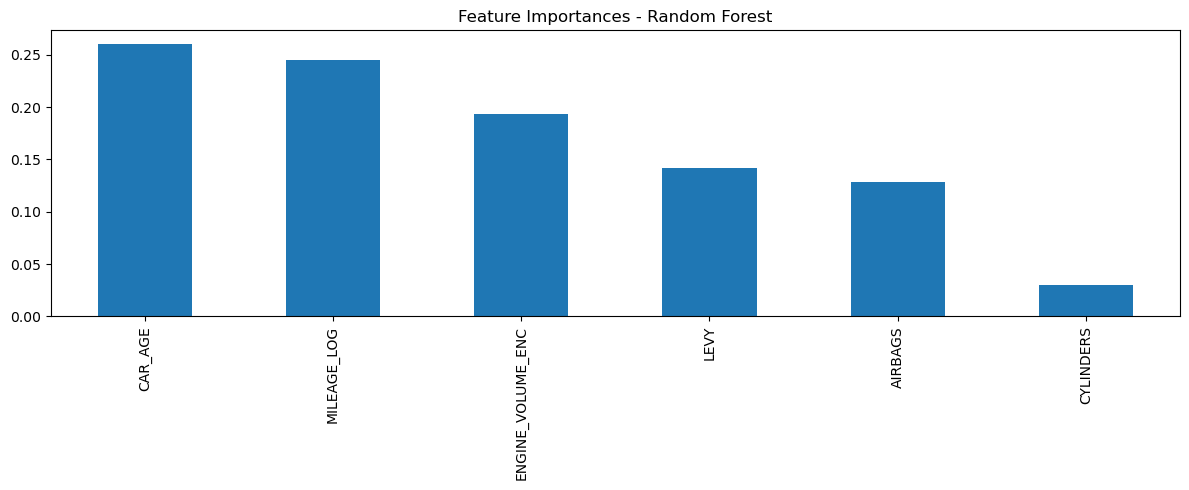

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(
    ascending=False
)
print(importances.round(4))

importances.sort_values(ascending=False).plot(kind="bar", figsize=(12, 5))
plt.title("Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

### 10.3 Recursive Feature Elimination (RFE)

In [36]:
estimator = LinearRegression()
rfe = RFE(estimator=estimator, n_features_to_select=5)
rfe.fit(X_train, y_train)

selected = X_train.columns[rfe.support_].tolist()
print("RFE selected features:", selected)

RFE selected features: ['MILEAGE_LOG', 'CYLINDERS', 'CAR_AGE', 'AIRBAGS', 'ENGINE_VOLUME_ENC']


---
## 11. Dimensionality Reduction With PCA

In [ ]:
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_train)

pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()
n_components = (cumulative_variance < 0.95).sum() + 1
print(
    f"Components needed to explain 95% variance: {n_components} out of {X_train.shape[1]} features"
)

Components needed to explain 95% variance: 5 out of 6 features


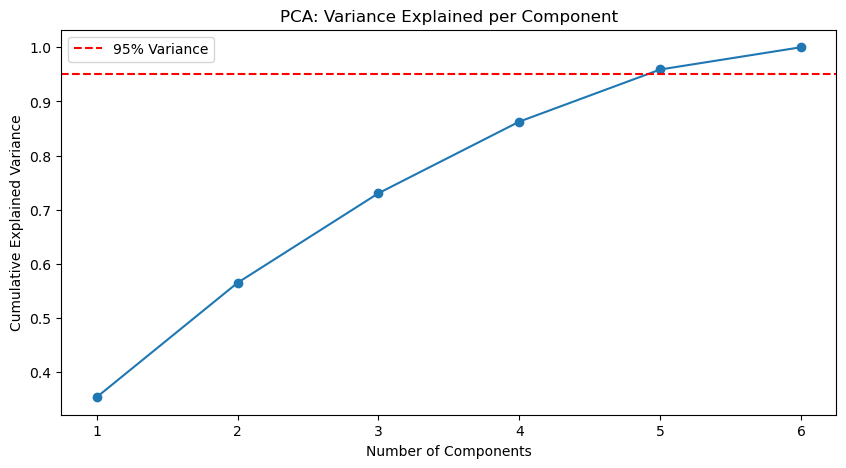


Cumulative variance per component:
  PC1: 0.3540
  PC2: 0.5652
  PC3: 0.7305
  PC4: 0.8627
  PC5: 0.9589
  PC6: 1.0000


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.95, color="r", linestyle="--", label="95% Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA: Variance Explained per Component")
plt.legend()
plt.show()

print("\nCumulative variance per component:")
for i, v in enumerate(cumulative_variance, 1):
    print(f"  PC{i}: {v:.4f}")

In [39]:
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_scaled)
X_test_pca = pca.transform(scaler_pca.transform(X_test))

print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape:  {X_test_pca.shape}")

X_train_pca shape: (12574, 5)
X_test_pca shape:  (3144, 5)
